In [1]:
# Cell 1: Import libraries

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report


C:\Users\nandi\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\_param_validation.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.3)
  from scipy.sparse import csr_matrix, issparse

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\nandi\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\nandi\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\nandi\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\nandi\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [2]:
# Cell 2: Check PyTorch and device

print("PyTorch version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


PyTorch version: 2.6.0+cpu
Using device: cpu


In [3]:
# Cell 3: Define transformations

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [4]:
# Cell 4: Download and load MNIST

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))


100%|██████████| 9.91M/9.91M [00:09<00:00, 1.08MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 61.4kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 848kB/s] 
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


Training samples: 60000
Testing samples: 10000


In [5]:
# Cell 5: Create DataLoaders

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Batch size:", batch_size)


Batch size: 64


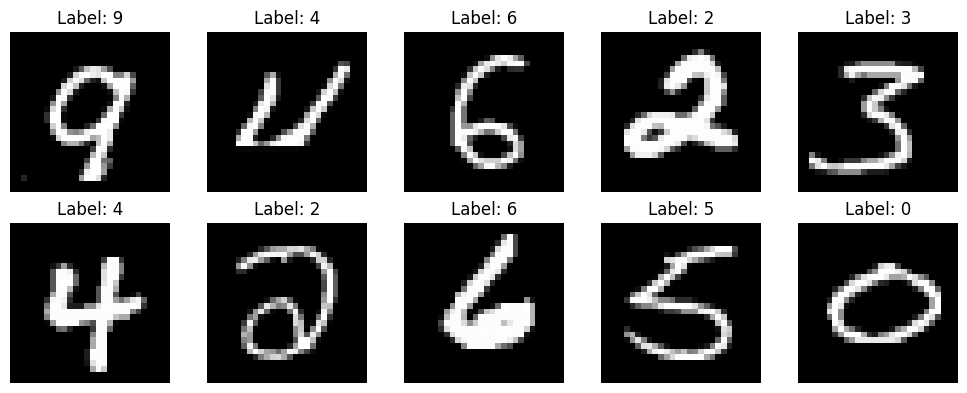

In [6]:
# Cell 6: Display sample images

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [7]:
# Cell 7: Define the neural network

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)


model = NeuralNetwork().to(device)

print(model)


NeuralNetwork(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [8]:
# Cell 8: Loss function and optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer: Adam")
print("Learning rate: 0.001")


Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.001


In [9]:
# Cell 9: Train the model

epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.4f}"
    )


Epoch [1/10] Loss: 0.4258 Accuracy: 0.8698
Epoch [2/10] Loss: 0.2228 Accuracy: 0.9323
Epoch [3/10] Loss: 0.1820 Accuracy: 0.9443
Epoch [4/10] Loss: 0.1597 Accuracy: 0.9501
Epoch [5/10] Loss: 0.1430 Accuracy: 0.9554
Epoch [6/10] Loss: 0.1304 Accuracy: 0.9593
Epoch [7/10] Loss: 0.1230 Accuracy: 0.9610
Epoch [8/10] Loss: 0.1161 Accuracy: 0.9633
Epoch [9/10] Loss: 0.1101 Accuracy: 0.9648
Epoch [10/10] Loss: 0.1059 Accuracy: 0.9657


In [10]:
# Cell 10: Evaluate on the test dataset

model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_loss = test_loss / len(test_loader)
test_accuracy = correct / total

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))


Test Loss: 0.0894
Test Accuracy: 0.9706


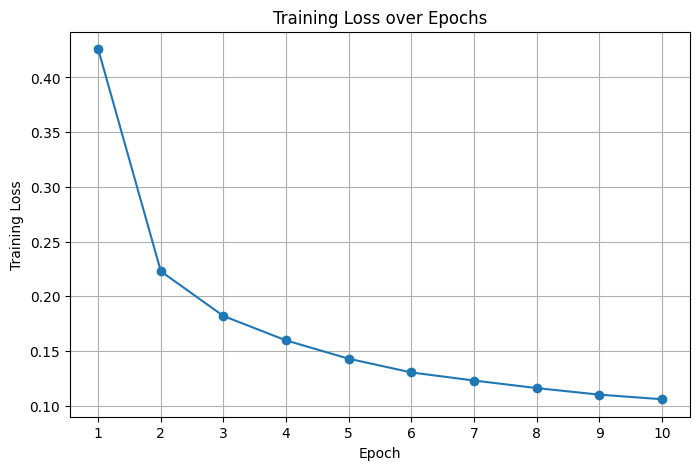

In [11]:
# Cell 11: Plot training loss

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss over Epochs")
plt.xticks(range(1, epochs + 1))
plt.grid(True)
plt.show()


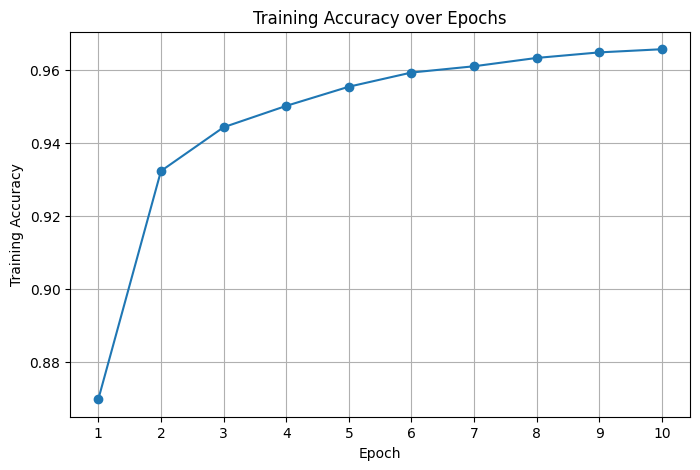

In [12]:
# Cell 12: Plot training accuracy

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy over Epochs")
plt.xticks(range(1, epochs + 1))
plt.grid(True)
plt.show()


In [13]:
# Cell 13: Generate predictions

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print("Total predictions:", len(all_predictions))


Total predictions: 10000


In [14]:
# Cell 14: Classification report

print(
    classification_report(
        all_labels,
        all_predictions,
        digits=4
    )
)


              precision    recall  f1-score   support

           0     0.9786    0.9806    0.9796       980
           1     0.9791    0.9885    0.9838      1135
           2     0.9692    0.9767    0.9730      1032
           3     0.9626    0.9673    0.9649      1010
           4     0.9742    0.9613    0.9677       982
           5     0.9532    0.9821    0.9674       892
           6     0.9761    0.9791    0.9776       958
           7     0.9743    0.9591    0.9667      1028
           8     0.9621    0.9641    0.9631       974
           9     0.9745    0.9465    0.9603      1009

    accuracy                         0.9706     10000
   macro avg     0.9704    0.9705    0.9704     10000
weighted avg     0.9707    0.9706    0.9706     10000



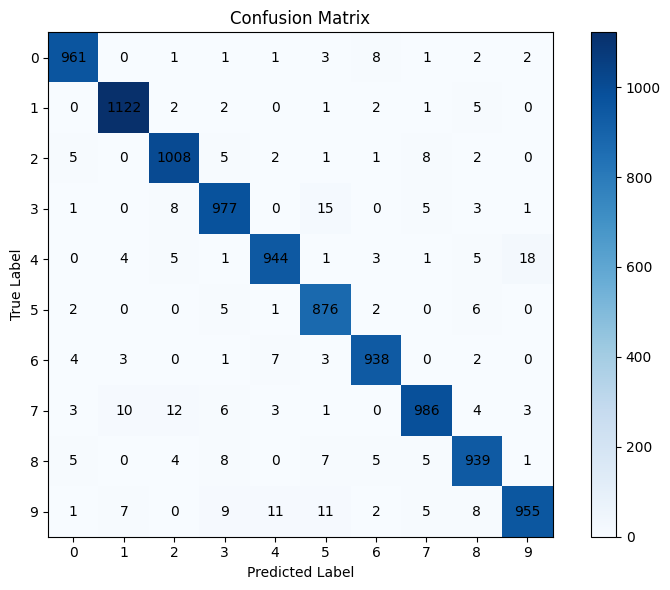

In [16]:
# Cell 16: Visualize confusion matrix

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(range(10))
plt.yticks(range(10))

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()


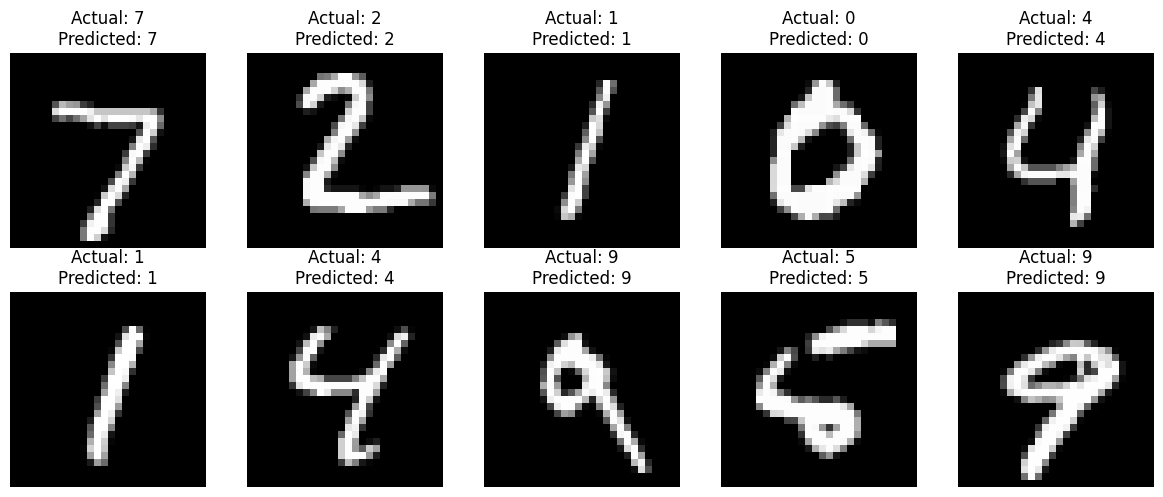

In [17]:
# Cell 17: Display actual and predicted labels

images, labels = next(iter(test_loader))

model.eval()

with torch.no_grad():
    outputs = model(images.to(device))
    _, predictions = torch.max(outputs, 1)

predictions = predictions.cpu()

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(
        f"Actual: {labels[i].item()}\n"
        f"Predicted: {predictions[i].item()}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


In [18]:
# Cell 18: Find incorrect predictions

incorrect_indices = np.where(
    all_predictions != all_labels
)[0]

print("Incorrect Predictions:", len(incorrect_indices))
print("Correct Predictions:", len(all_labels) - len(incorrect_indices))


Incorrect Predictions: 294
Correct Predictions: 9706


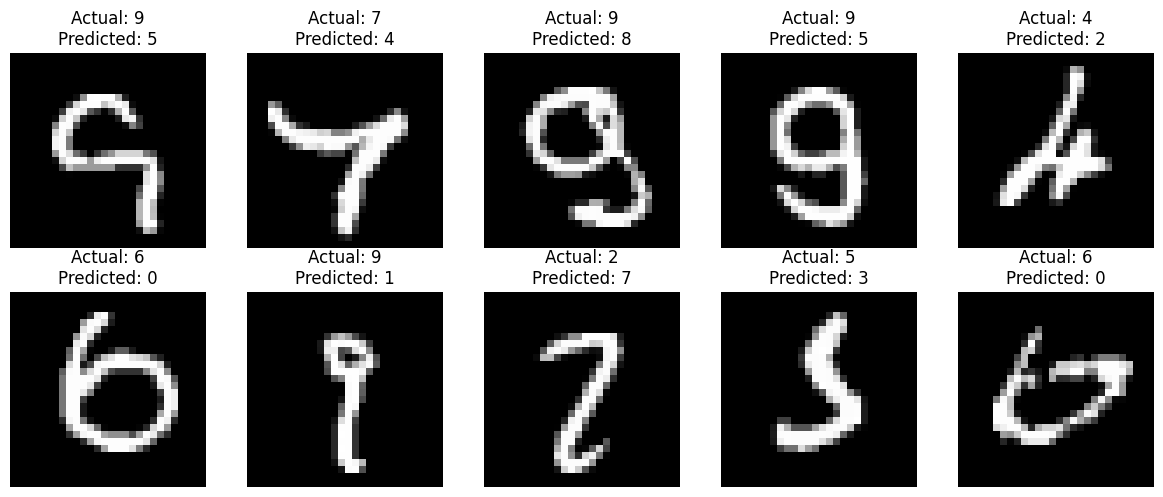

In [19]:
# Cell 19: Display incorrect predictions

num_images = min(10, len(incorrect_indices))

plt.figure(figsize=(12, 5))

for i in range(num_images):

    index = incorrect_indices[i]

    image, label = test_dataset[index]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(
        f"Actual: {label}\n"
        f"Predicted: {all_predictions[index]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


In [20]:
# Cell 20: Final performance summary

print("FINAL MODEL PERFORMANCE")
print("=======================")
print("Model: PyTorch Neural Network")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))
print("Incorrect Predictions:", len(incorrect_indices))
print("Correct Predictions:", len(all_labels) - len(incorrect_indices))


FINAL MODEL PERFORMANCE
Model: PyTorch Neural Network
Test Loss: 0.0894
Test Accuracy: 0.9706
Incorrect Predictions: 294
Correct Predictions: 9706
